In [95]:

import os

CIRCLES_OS_PATH = 'data/circles/'
RECTANGLES_OS_PATH = 'data/rectangles/'
TRIANGLES_OS_PATH = 'data/triangles/'
MODELS_DIR = 'models/'

# Tensorflow is an open-source ML lib
import tensorflow as tf

# Keras is Tensorflow's high-level API for deep learning
from tensorflow import keras

import tensorflow_model_optimization as tfmot

# Numpy is a math lib
import numpy as np

# Panda is a data manipulation lib
import pandas as pd

import tempfile

# Matplotlib is a graphing lib
import matplotlib.pyplot as plt

# Math is Python's math lib
import math

import random

import glob

import PIL
from PIL import Image

# Set seed for experimental reproducibility
seed = 1
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

# Import Dataset

rectangle


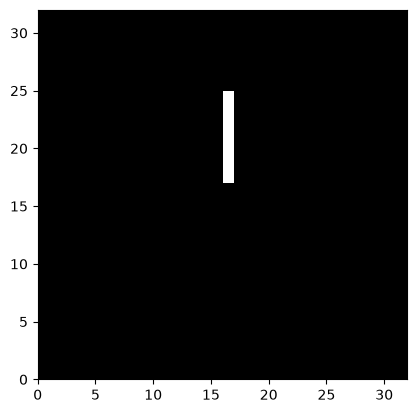

In [96]:
SAMPLES = 5000
WIDTH = 32 # Change as needed
HEIGHT = 32 # Changed as needed
np.set_printoptions(threshold=np.inf)

def show_screen(axs, screen):
    axs.imshow(screen, cmap='gray', vmin=0, vmax=1,extent=(0,WIDTH,0,HEIGHT))

label_array = ["circle", "rectangle", "triangle"]
label_to_index = dict((name, index) for index,name in enumerate(label_array))

def get_img(img_path):
    return np.load(img_path)

# Create tuple of whole dataset
def get_ds(data_path):
    labels = np.zeros(SAMPLES*3)
    images = np.zeros((SAMPLES*3, WIDTH, HEIGHT))
    img_paths = list()

    for img_path in glob.glob(F'{data_path}/**/*'):
        img_paths.append(img_path)
  
    random.shuffle(img_paths)
    for i, img_path in enumerate(img_paths):
        images[i] = get_img(img_path)
        head, tail = os.path.split(img_path)
        label_id = tail.split('-')[0]
        labels[i] = label_to_index[label_id]
    
    return images, labels


TRAIN_SPLIT = int(0.6*(SAMPLES*3))
TEST_SPLIT = int(0.2*(SAMPLES*3) + TRAIN_SPLIT)

full_x, full_y = get_ds('data')

x_train, x_test, x_validate = np.split(full_x, [TRAIN_SPLIT, TEST_SPLIT])
y_train, y_test, y_validate = np.split(full_y, [TRAIN_SPLIT, TEST_SPLIT])

show_screen(plt, x_validate[4])
print(label_array[int(y_validate[4])])




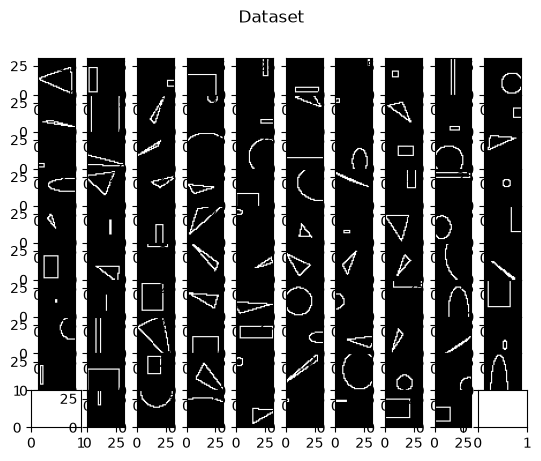

In [97]:
# Show Dataset
fig = plt.figure()
gs = fig.add_gridspec(10,10, hspace=0,wspace=0)
axs = gs.subplots()
fig.suptitle('Dataset')

j = 0
for i in range(99):
    show_screen(axs[j][int(i%10)], x_test[i])
    if i%10 == 0 and i != 0:
        j += 1

# Create The Model

In [116]:

#model = tf.keras.Sequential([
#    tf.keras.layers.Input(shape=(WIDTH,HEIGHT,1)),
#    tf.keras.layers.Conv2D(32, 3, activation='relu'),
#    tf.keras.layers.MaxPooling2D(),
#    tf.keras.layers.Conv2D(32, 3, activation='relu'),
#    tf.keras.layers.MaxPooling2D(),
#    tf.keras.layers.Conv2D(32, 3, activation='relu'),
#    tf.keras.layers.MaxPooling2D(),
#   tf.keras.layers.Flatten(),
#    tf.keras.layers.Dense(64, activation='relu'),
#    tf.keras.layers.Dense(3)
#])


model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(WIDTH,HEIGHT,1)),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Conv2D(32, 3, activation='relu'),
    tf.keras.layers.MaxPooling2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.001)),
    tf.keras.layers.Dropout(0.3),
    #tf.keras.layers.Softmax(),
    tf.keras.layers.Dense(3, activation='softmax', kernel_regularizer=keras.regularizers.l2(0.001)),
])

model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=['accuracy']
)

model.summary()

Model: "sequential_6"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_18 (Conv2D)          (None, 30, 30, 32)        320       
                                                                 
 max_pooling2d_18 (MaxPooli  (None, 15, 15, 32)        0         
 ng2D)                                                           
                                                                 
 conv2d_19 (Conv2D)          (None, 13, 13, 32)        9248      
                                                                 
 max_pooling2d_19 (MaxPooli  (None, 6, 6, 32)          0         
 ng2D)                                                           
                                                                 
 conv2d_20 (Conv2D)          (None, 4, 4, 32)          9248      
                                                                 
 max_pooling2d_20 (MaxPooli  (None, 2, 2, 32)         

## Train The Model

In [117]:
history = model.fit(
    x_train, y_train, epochs=15, batch_size=64, validation_data=(x_validate, y_validate)
)

Epoch 1/15
141/141 [==============================] - 1s 4ms/step - loss: 0.8339 - accuracy: 0.6071 - val_loss: 0.5499 - val_accuracy: 0.7610
Epoch 2/15
141/141 [==============================] - 1s 4ms/step - loss: 0.5060 - accuracy: 0.8061 - val_loss: 0.3930 - val_accuracy: 0.8723
Epoch 3/15
141/141 [==============================] - 1s 4ms/step - loss: 0.3867 - accuracy: 0.8697 - val_loss: 0.3310 - val_accuracy: 0.8873
Epoch 4/15
141/141 [==============================] - 1s 4ms/step - loss: 0.3153 - accuracy: 0.8969 - val_loss: 0.2889 - val_accuracy: 0.9043
Epoch 5/15
141/141 [==============================] - 0s 3ms/step - loss: 0.2755 - accuracy: 0.9153 - val_loss: 0.2498 - val_accuracy: 0.9187
Epoch 6/15
141/141 [==============================] - 0s 4ms/step - loss: 0.2563 - accuracy: 0.9227 - val_loss: 0.3014 - val_accuracy: 0.9003
Epoch 7/15
141/141 [==============================] - 0s 4ms/step - loss: 0.2420 - accuracy: 0.9246 - val_loss: 0.2332 - val_accuracy: 0.9307
Epoch 

In [118]:
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(F'Test Complete (Loss: {loss:.4f}, Accuracy: {acc:.4f})')

Test Complete (Loss: 0.1749, Accuracy: 0.9493)


In [119]:
def get_error(predictions, y_test):
    i = 0
    number_correct = 0
    for element in predictions:
        most_probable = max(element)
        if most_probable == element[0]:
            print(F'circle - {label_array[int(y_test[i])]}')
            if int(y_test[i]) == 0:
                number_correct += 1
        elif most_probable == element[1]:
            print(F'rectangle - {label_array[int(y_test[i])]}')
            if int(y_test[i]) == 1:
                number_correct += 1
        else:
            print(F'triangle - {label_array[int(y_test[i])]}')
            if int(y_test[i]) == 2:
                number_correct += 1
        i += 1
    print(F'Number Correct = {number_correct}/{int((SAMPLES*3)*0.2)} ({(number_correct/int((SAMPLES*3)*0.2)*100):.0f}%)')

predictions = model.predict(x_test)
get_error(predictions, y_test)

94/94 [==============================] - 0s 1ms/step
rectangle - rectangle
rectangle - rectangle
rectangle - rectangle
rectangle - rectangle
rectangle - rectangle
rectangle - rectangle
rectangle - rectangle
rectangle - rectangle
rectangle - rectangle
circle - circle
triangle - triangle
rectangle - rectangle
triangle - triangle
circle - circle
rectangle - rectangle
triangle - triangle
rectangle - circle
triangle - triangle
rectangle - rectangle
rectangle - rectangle
triangle - triangle
triangle - triangle
triangle - triangle
circle - circle
circle - circle
rectangle - rectangle
circle - circle
rectangle - rectangle
circle - circle
triangle - triangle
rectangle - rectangle
triangle - triangle
triangle - triangle
triangle - triangle
rectangle - rectangle
circle - circle
triangle - triangle
rectangle - rectangle
rectangle - rectangle
circle - circle
circle - circle
rectangle - rectangle
rectangle - rectangle
triangle - triangle
circle - circle
triangle - triangle
rectangle - rectangle
tria

# Optimize

In [120]:
model.save('models/saved_model.keras')

In [121]:
num_calibration_steps = 1
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]

In [122]:
def representative_dataset_gen():
    for _ in range(num_calibration_steps):
        yield [tf.random.uniform(shape=(1,WIDTH,HEIGHT,1), dtype=tf.float32)]

converter.representative_dataset = representative_dataset_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS]
tflite_quant_model2 = converter.convert()
open('models/quant_model.tflite', "wb").write(tflite_quant_model2)



INFO:tensorflow:Assets written to: C:\Users\Duckb\AppData\Local\Temp\tmpl_9cdcy2\assets


INFO:tensorflow:Assets written to: C:\Users\Duckb\AppData\Local\Temp\tmpl_9cdcy2\assets
c:\Programming\python\TinyML\.venv-1\Lib\site-packages\tensorflow\lite\python\convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


37104

In [123]:
interpreter = tf.lite.Interpreter(model_content=tflite_quant_model2, experimental_op_resolver_type=tf.lite.experimental.OpResolverType.BUILTIN_REF)
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
interpreter.allocate_tensors()
print(input_details)
print(output_details)

predictions = []
i = 0
for img in x_test:  
    img = img.reshape((WIDTH,HEIGHT,1))
    interpreter.set_tensor(input_details[0]['index'], [img.astype('float32')])
    interpreter.invoke()
    output_data = interpreter.get_tensor(output_details[0]['index'])
    predictions.append(output_data[0])
    print(F'Done {i}/{x_test.shape[0]}')
    i += 1
predictions = np.array(predictions)
get_error(predictions, y_test)

c:\Programming\python\TinyML\.venv-1\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


[{'name': 'serving_default_input_7:0', 'index': 0, 'shape': array([ 1, 32, 32,  1], dtype=int32), 'shape_signature': array([-1, 32, 32,  1], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}]
[{'name': 'StatefulPartitionedCall:0', 'index': 23, 'shape': array([1, 3], dtype=int32), 'shape_signature': array([-1,  3], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}]
Done 0/3000
Done 1/3000
Done 2/3000
Done 3/3000
Done 4/3000
Done 5/3000
Done 6/3000
Done 7/3000
Done 8/3000
Done 9/3000
Done 10/3000
Done 11/3000
Done 12/3000
Done 13/3000
Done 14/3000
Done 15/3000
Done 16/3000
Done 17/3000
Done 18/3000


In [129]:
img = Image.open('test_cir_2.bmp')
a = np.array(img).reshape(WIDTH,HEIGHT,1).astype('float32')

a = (a - np.min(a))/np.ptp(a)
a = a.round()

interpreter.set_tensor(input_details[0]['index'], [a.astype('float32')])
interpreter.invoke()
output_data = interpreter.get_tensor(output_details[0]['index'])
print(output_data)

[[0.98046875 0.         0.01953125]]


# Convert to C source file

In [33]:
# Install xxd if it is not available
! apt-get update && apt-get -qq install xxd

# Save the file as a C source file
! xxd -i 'models/quant_model.tflite' > 'models/shape_model_quant.cc'

# Update variable names using sed
REPLACE_TEXT = 'models/model_quant.tflite'.replace('/', '_').replace('.', '_')
! sed -i 's/'{REPLACE_TEXT}'/g_model/g' 'models/shape_model_quant.cc'

# Print the source file
! cat 'models/shape_model_quant.cc'

'apt-get' is not recognized as an internal or external command,
operable program or batch file.
The system cannot find the path specified.
'sed' is not recognized as an internal or external command,
operable program or batch file.
'cat' is not recognized as an internal or external command,
operable program or batch file.
